# New-sensor baseline comparison (PEMS03 / PEMS04)

Grouped-bar comparison of **newly-added-sensor** forecast error (Avg horizon)
for every baseline + **Ours (A2TTA)**, styled after the reference demo figure.

- **Source:** `tables/tsas_new_sensors_part1.tex` (parsed directly, so the figure
  tracks the table).
- **Layout:** 2 rows (PEMS03, PEMS04) × 3 cols (MAE, RMSE, MAPE).
- **Style:** Okabe-Ito colour-blind-safe palette, one bar per method coloured by
  category, top legend, value label on each bar, **Ours** in vermillion.
- **Outliers:** error metrics where lower is better; each panel is scaled to its
  competitive range, and extreme-failure bars are clipped (hatched, with the
  true value annotated `↑`).
- **Outputs:** `new_sensor_baselines.png` (400 dpi) and `new_sensor_baselines.pdf`
  (true vector — `pdf.fonttype=42`, no rasterized content).

Run all cells with the **stg** kernel to regenerate the PNG + PDF.


In [2]:
import os, os.path as osp, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

%matplotlib inline
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 8, "axes.linewidth": 0.7, "hatch.linewidth": 0.5,
    "pdf.fonttype": 42, "ps.fonttype": 42,   # selectable vector text in the PDF
    "savefig.facecolor": "white", "figure.facecolor": "white",
})

REPO = osp.dirname(os.getcwd())             # .../evo-xxltraffic  (notebook lives in figs_paper/)
TEX  = osp.join(REPO, "tables", "tsas_new_sensors_part1.tex")


In [3]:
# Column schema: (group, label) in the exact left-to-right order of the .tex header.
COLUMNS = [
    ("Static STGNN Backbones", "DCRNN"), ("Static STGNN Backbones", "ASTGNN"),
    ("Static STGNN Backbones", "TGCN"),  ("Static STGNN Backbones", "GWN"),
    ("Naïve Schemes", "Pretrain"), ("Naïve Schemes", "Retrain"),
    ("Naïve Schemes", "OL-NN"),    ("Naïve Schemes", "OL-AN"),
    ("Evolving-Graph Continual", "TrafStm"), ("Evolving-Graph Continual", "PECPM"),
    ("Evolving-Graph Continual", "STKEC"),   ("Evolving-Graph Continual", "EAC"),
    ("Retrieval / TTC", "STRAP"), ("Retrieval / TTC", "ST-TTC"),
    ("Other Static Backbones", "STID"), ("Other Static Backbones", "STNorm"),
    ("Other Static Backbones", "iTrans"), ("Other Static Backbones", "DLinear"),
    ("Ours", "A2TTA"),
]
LABELS = [l for _g, l in COLUMNS]
GROUPS = [g for g, _l in COLUMNS]

GROUP_ORDER = ["Static STGNN Backbones", "Naïve Schemes", "Evolving-Graph Continual",
               "Retrieval / TTC", "Other Static Backbones", "Ours"]
# Okabe-Ito colour-blind-safe palette; "Ours" = vermillion (most distinct).
GROUP_COLOR = {
    "Static STGNN Backbones":   "#0072B2", "Naïve Schemes":            "#56B4E9",
    "Evolving-Graph Continual": "#009E73", "Retrieval / TTC":          "#CC79A7",
    "Other Static Backbones":   "#E69F00", "Ours":                     "#D55E00",
}
GROUP_LEGEND = {
    "Static STGNN Backbones": "Static STGNN", "Naïve Schemes": "Naïve",
    "Evolving-Graph Continual": "Evolving Continual", "Retrieval / TTC": "Retrieval / TTC",
    "Other Static Backbones": "Other Static", "Ours": "Ours",
}
DATASETS = ["PEMS03", "PEMS04"]
METRICS  = ["MAE", "RMSE", "MAPE"]
HORIZON  = "Avg"

XTICK_ROTATION = 45   # <-- tilt of the x-axis method names, in degrees (90 = vertical, 0 = horizontal)


In [ ]:
def parse_tex(path):
    """data[(dataset, metric, horizon)] = [mean per method] in COLUMNS order."""
    txt = open(path).read()
    body = txt.split(r"\midrule", 1)[1].split(r"\bottomrule", 1)[0]
    data, cur_ds, cur_metric = {}, None, None
    num = re.compile(r"(-?\d+\.\d+)")
    for frag in body.split(r"\\"):
        if "$_{\\pm" not in frag:
            continue
        frag = re.sub(r"\\cmidrule\(lr\)\{[^}]*\}", "", frag)
        cells = [c.strip() for c in frag.split("&")]
        if len(cells) < 3 + len(COLUMNS):
            continue
        meta, mcells = cells[:3], cells[3:3 + len(COLUMNS)]
        m0 = re.search(r"PEMS\d+", meta[0])
        if m0: cur_ds = m0.group(0)
        for name in ("MAE", "RMSE", "MAPE"):
            if name in meta[1]: cur_metric = name
        vals = [float(num.search(c).group(1)) if num.search(c) else np.nan for c in mcells]
        data[(cur_ds, cur_metric, meta[2])] = vals
    return data

data = parse_tex(TEX)
print("parsed panels:", [k for k in data if k[2] == HORIZON and k[0] in DATASETS])


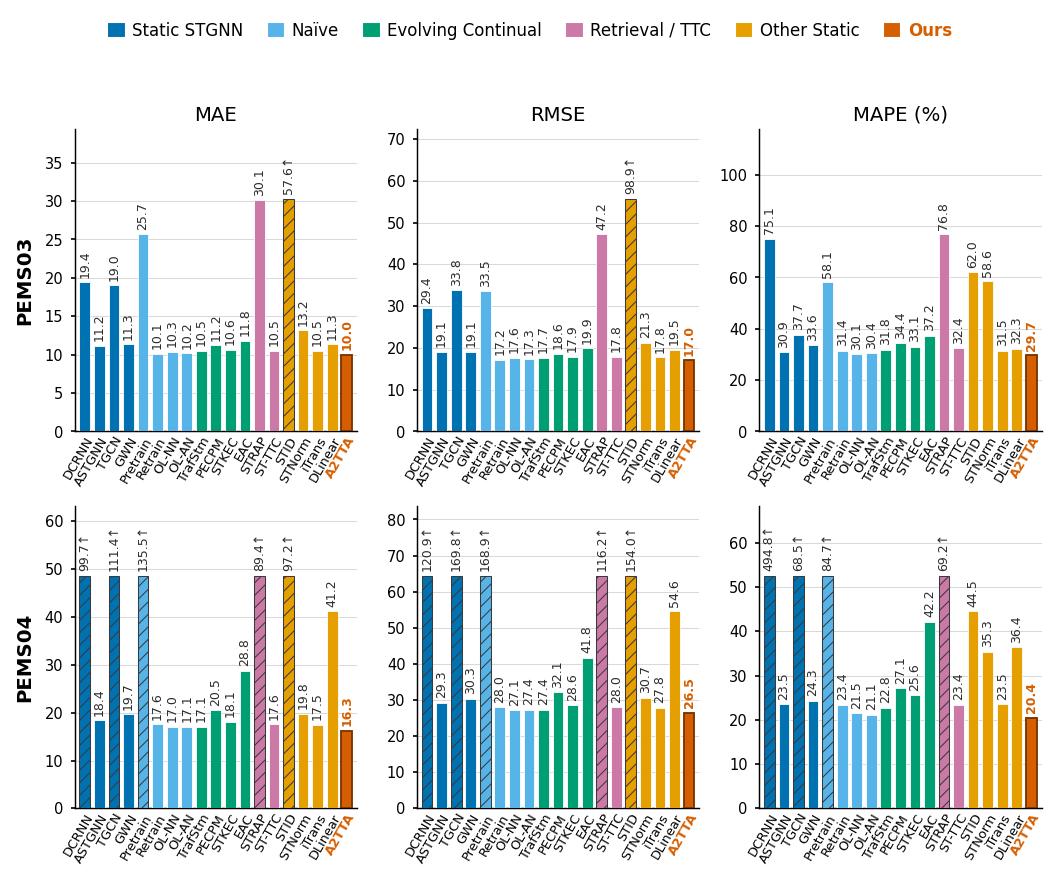

In [ ]:
bar_colors = [GROUP_COLOR[g] for g in GROUPS]
x = np.arange(len(LABELS))
XTICK_ROTATION1=60

fig, axes = plt.subplots(len(DATASETS), len(METRICS), figsize=(7.1, 5.7), dpi=150)

for r, ds in enumerate(DATASETS):
    for c, metric in enumerate(METRICS):
        ax = axes[r, c]
        vals = np.array(data[(ds, metric, HORIZON)], dtype=float)

        # Per-panel cap to the competitive range (the demo also scales each
        # subplot independently); extreme failures are clipped + hatched.
        vmin = np.nanmin(vals)
        cap = 1.18 * np.nanmax(vals[vals <= 3.0 * vmin])
        disp = np.minimum(vals, cap)
        clip_mask = vals > cap + 1e-9

        bars = ax.bar(x, disp, width=0.74, color=bar_colors,
                      edgecolor="white", linewidth=0.4, zorder=3)
        for b, clipped in zip(bars, clip_mask):
            if clipped:
                b.set_hatch("////"); b.set_edgecolor("#3a3a3a"); b.set_linewidth(0.5)
        bars[-1].set_edgecolor("#7a3500"); bars[-1].set_linewidth(0.9)   # Ours pops

        ax.set_ylim(0, cap * 1.30)
        ax.set_xlim(-0.7, len(LABELS) - 0.3)
        for i, (b, v, clipped) in enumerate(zip(bars, vals, clip_mask)):
            is_ours = i == len(LABELS) - 1
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + cap * 0.02,
                    f"{v:.1f}↑" if clipped else f"{v:.1f}",
                    ha="center", va="bottom", rotation=90, fontsize=6.0,
                    color=GROUP_COLOR["Ours"] if is_ours else "#2b2b2b",
                    fontweight="bold" if is_ours else "normal", zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels(LABELS, rotation=XTICK_ROTATION1, fontsize=6.2,
                           ha=("center" if XTICK_ROTATION1 == 90 else "right"),
                           rotation_mode="anchor")
        for tl, g in zip(ax.get_xticklabels(), GROUPS):
            if g == "Ours":
                tl.set_color(GROUP_COLOR["Ours"]); tl.set_fontweight("bold")
        ax.tick_params(axis="y", labelsize=7.0, length=2)
        ax.tick_params(axis="x", length=0, pad=1.5)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        ax.grid(axis="y", color="0.85", linewidth=0.5, zorder=0); ax.set_axisbelow(True)

        if c == 0: ax.set_ylabel(ds, fontsize=9.5, fontweight="bold", labelpad=5)
        if r == 0: ax.set_title(metric + (" (%)" if metric == "MAPE" else ""),
                                fontsize=9.5, pad=4)

handles = [Patch(facecolor=GROUP_COLOR[g], edgecolor="white", label=GROUP_LEGEND[g])
           for g in GROUP_ORDER]
leg = fig.legend(handles=handles, ncol=6, loc="upper center",
                 bbox_to_anchor=(0.5, 1.025), frameon=False, fontsize=8.0,
                 handlelength=1.1, handleheight=1.1, columnspacing=1.4, handletextpad=0.4)
for t in leg.get_texts():
    if t.get_text() == "Ours":
        t.set_color(GROUP_COLOR["Ours"]); t.set_fontweight("bold")

fig.tight_layout(rect=[0, 0, 1, 0.93])

fig.savefig("new_sensor_baselines.png", dpi=400, bbox_inches="tight")
fig.savefig("new_sensor_baselines.pdf", bbox_inches="tight")   # true vector
plt.show()
print("wrote new_sensor_baselines.png + .pdf")


## 3×2 variant (rows = metrics, cols = datasets)

Same data and style, transposed to a tall 3-row × 2-col layout. Saves `new_sensor_baselines2.{png,pdf}`.

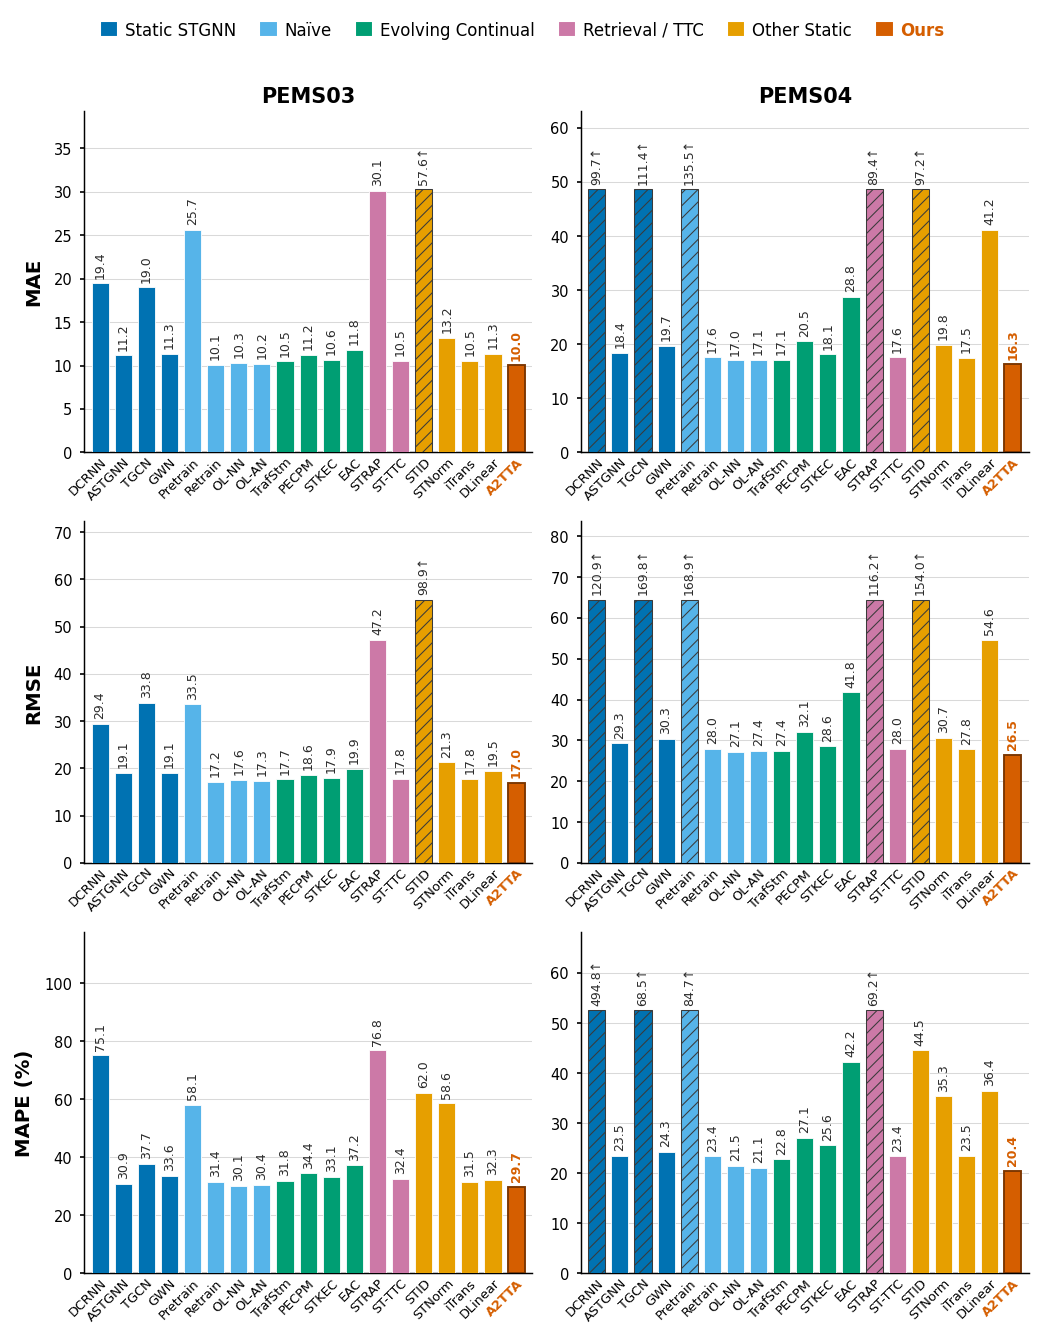

In [ ]:
# ---- 3x2 variant: rows = metrics, cols = datasets ----------------------------
# Same data/style as above, transposed; method labels only on the bottom row.
fig2, axes2 = plt.subplots(len(METRICS), len(DATASETS), figsize=(7.0, 8.8), dpi=150)

for r, metric in enumerate(METRICS):
    for c, ds in enumerate(DATASETS):
        ax = axes2[r, c]
        vals = np.array(data[(ds, metric, HORIZON)], dtype=float)
        vmin = np.nanmin(vals)
        cap = 1.18 * np.nanmax(vals[vals <= 3.0 * vmin])
        disp = np.minimum(vals, cap)
        clip_mask = vals > cap + 1e-9

        bars = ax.bar(x, disp, width=0.74, color=bar_colors,
                      edgecolor="white", linewidth=0.4, zorder=3)
        for b, clipped in zip(bars, clip_mask):
            if clipped:
                b.set_hatch("////"); b.set_edgecolor("#3a3a3a"); b.set_linewidth(0.5)
        bars[-1].set_edgecolor("#7a3500"); bars[-1].set_linewidth(0.9)

        ax.set_ylim(0, cap * 1.30)
        ax.set_xlim(-0.7, len(LABELS) - 0.3)
        for i, (b, v, clipped) in enumerate(zip(bars, vals, clip_mask)):
            is_ours = i == len(LABELS) - 1
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + cap * 0.02,
                    f"{v:.1f}↑" if clipped else f"{v:.1f}",
                    ha="center", va="bottom", rotation=90, fontsize=6.0,
                    color=GROUP_COLOR["Ours"] if is_ours else "#2b2b2b",
                    fontweight="bold" if is_ours else "normal", zorder=4)

        ax.set_xticks(x)                               # every subplot shows the method names
        ax.set_xticklabels(LABELS, rotation=XTICK_ROTATION, fontsize=6.2,
                           ha=("center" if XTICK_ROTATION == 90 else "right"),
                           rotation_mode="anchor")
        for tl, g in zip(ax.get_xticklabels(), GROUPS):
            if g == "Ours":
                tl.set_color(GROUP_COLOR["Ours"]); tl.set_fontweight("bold")
        ax.tick_params(axis="y", labelsize=7.0, length=2)
        ax.tick_params(axis="x", length=0, pad=1.5)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        ax.grid(axis="y", color="0.85", linewidth=0.5, zorder=0); ax.set_axisbelow(True)

        if c == 0: ax.set_ylabel(metric + (" (%)" if metric == "MAPE" else ""),
                                 fontsize=9.5, fontweight="bold", labelpad=5)
        if r == 0: ax.set_title(ds, fontsize=10, pad=4, fontweight="bold")

leg = fig2.legend(handles=handles, ncol=6, loc="upper center",
                  bbox_to_anchor=(0.5, 1.012), frameon=False, fontsize=8.0,
                  handlelength=1.1, handleheight=1.1, columnspacing=1.4, handletextpad=0.4)
for t in leg.get_texts():
    if t.get_text() == "Ours":
        t.set_color(GROUP_COLOR["Ours"]); t.set_fontweight("bold")

fig2.tight_layout(rect=[0, 0, 1, 0.965])

fig2.savefig("new_sensor_baselines2.png", dpi=400, bbox_inches="tight")
fig2.savefig("new_sensor_baselines2.pdf", bbox_inches="tight")   # true vector
plt.show()
print("wrote new_sensor_baselines2.png + .pdf")
